In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier, plot_importance


In [13]:
#=====================Đọc file====================
df = pd.read_csv("student_lifestyle_100k.csv")

print (df.head())

print("Số dòng:", df.shape[0])
print("Số cột:",  df.shape[1])

print("Dữ liệu các cột là:", df.dtypes)

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
Số dòng: 100000
Số cột: 11
Dữ liệu các cột là: Student_ID              int64
Age                     int64
Gender    

In [14]:
#=============Tiền xử lý dữ liệu===============

#kiếm tra các dòng bị trùng
print("Số dòng bị trùng là:", df.duplicated().sum())
#Xóa số dòng bị trùng
df = df.drop_duplicates()

#kiểm tra tổng số giá trị thiếu
print("Số giá trị thiếu là:", df.isnull().sum().sum())

# Xóa các cột 'Unnamed' có nhiều giá trị thiếu
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col], errors='ignore')

#Sau đó, loại bỏ các dòng có giá trị thiếu còn lại
df = df.dropna()

#Chuẩn hóa dữ liệu
#Xóa ID
df = df.drop("Student_ID", axis =1)
# XGBoost không hiểu text nên phải chuyển text sang số
df = pd.get_dummies(df, columns=["Gender", "Department"])
#chuyển đổi nhãn sang số
df["Depression"] = df["Depression"].astype(int)

print(df.head())
print(df.dtypes)

Số dòng bị trùng là: 0
Số giá trị thiếu là: 0
   Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   22  3.50             7.3          3.3                 3.4   
1   20  2.72             5.5          7.2                 6.0   
2   20  3.01             5.4          2.3                 1.8   
3   21  3.63             8.1          2.0                 4.6   
4   19  3.14             6.8          2.6                 4.3   

   Physical_Activity  Stress_Level  Depression  Gender_Female  Gender_Male  \
0                114             5           0           True        False   
1                142             2           0          False         True   
2                137             3           0          False         True   
3                130             3           0          False         True   
4                  4             6           0          False         True   

   Department_Arts  Department_Business  Department_Engineering  \
0            False         

Age: 0 outliers
CGPA: 0 outliers
Sleep_Duration: 369 outliers
Study_Hours: 432 outliers
Social_Media_Hours: 328 outliers
Physical_Activity: 0 outliers
Stress_Level: 478 outliers


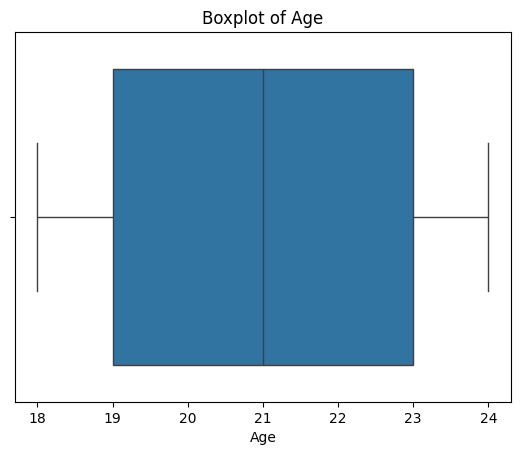

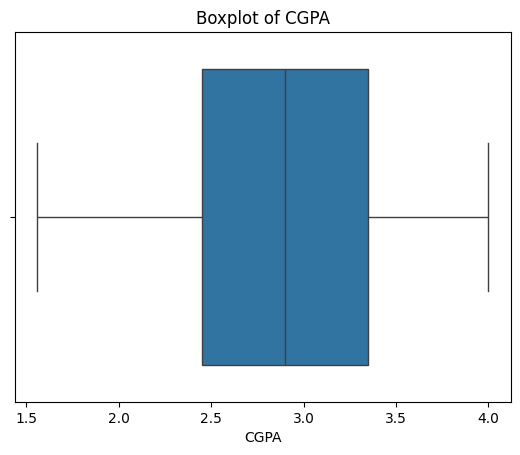

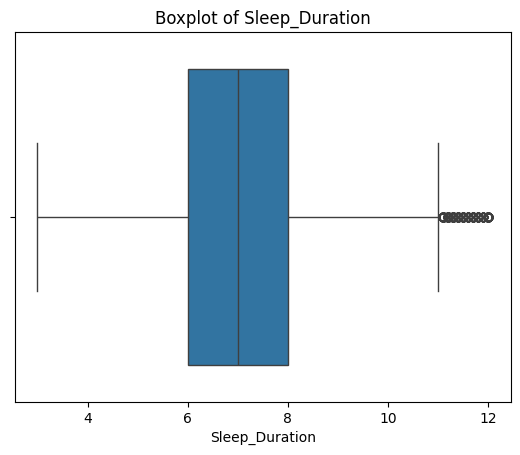

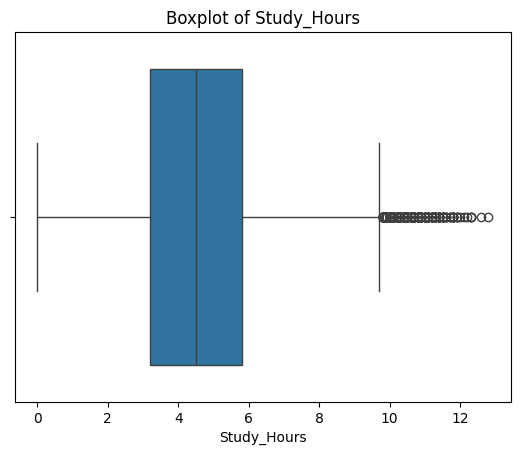

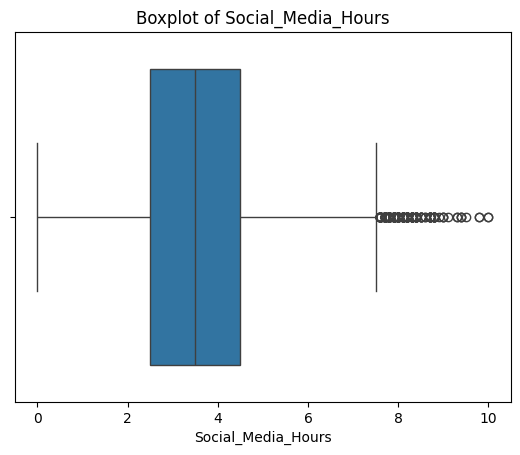

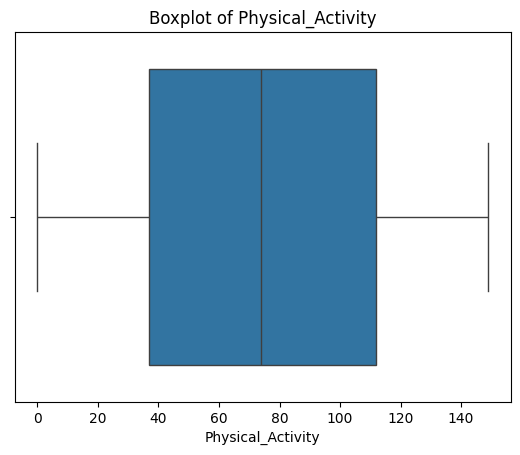

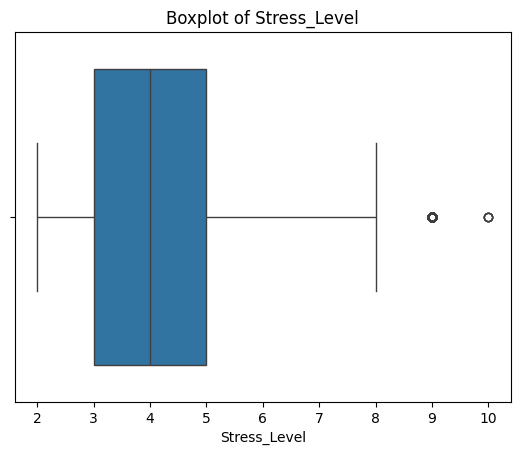

In [15]:
#==============kiểm tra giá trị ngoại lai=================
num_cols = [
    "Age", "CGPA", "Sleep_Duration", "Study_Hours",
    "Social_Media_Hours", "Physical_Activity", "Stress_Level"
]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
#===============vẽ biểu đồ biểu diễn ngoại lai===========
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
#================tạo cột mới=====================
# Tạo cột tổng thời gian hoạt động
df["Total_Activity"] = df["Study_Hours"] + df["Social_Media_Hours"]

#tạo cột tỷ lệ học/giải trí
df["Study_Ratio"] = df["Study_Hours"] / (df["Social_Media_Hours"] + 1)
#tạo cột mức stress kết hợp
df["Stress_Per_Study"] = df["Stress_Level"] / (df["Study_Hours"] + 1)
#tạo cột nhóm CGPA
df["CGPA_Level"] = pd.cut(df["CGPA"],
                         bins=[0, 2.5, 3.2, 4],
                         labels=["Low", "Medium", "High"])
df = pd.get_dummies(df, columns=["CGPA_Level"])

print(df.head())
print(df.dtypes)


   Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   22  3.50             7.3          3.3                 3.4   
1   20  2.72             5.5          7.2                 6.0   
2   20  3.01             5.4          2.3                 1.8   
3   21  3.63             8.1          2.0                 4.6   
4   19  3.14             6.8          2.6                 4.3   

   Physical_Activity  Stress_Level  Depression  Gender_Female  Gender_Male  \
0                114             5           0           True        False   
1                142             2           0          False         True   
2                137             3           0          False         True   
3                130             3           0          False         True   
4                  4             6           0          False         True   

   ...  Department_Business  Department_Engineering  Department_Medical  \
0  ...                False                   False              

Accuracy: 0.73245
              precision    recall  f1-score   support

           0       0.95      0.75      0.83     17995
           1       0.21      0.61      0.31      2005

    accuracy                           0.73     20000
   macro avg       0.58      0.68      0.57     20000
weighted avg       0.87      0.73      0.78     20000



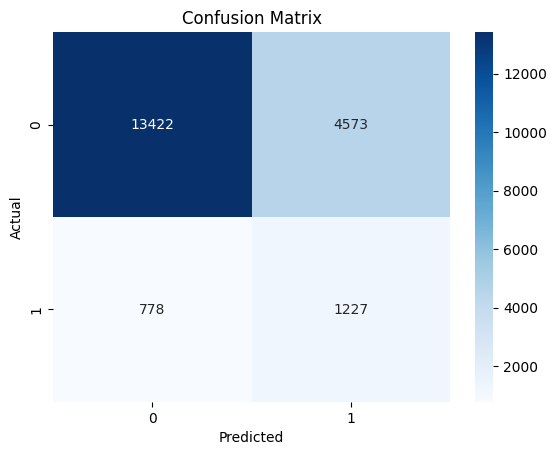

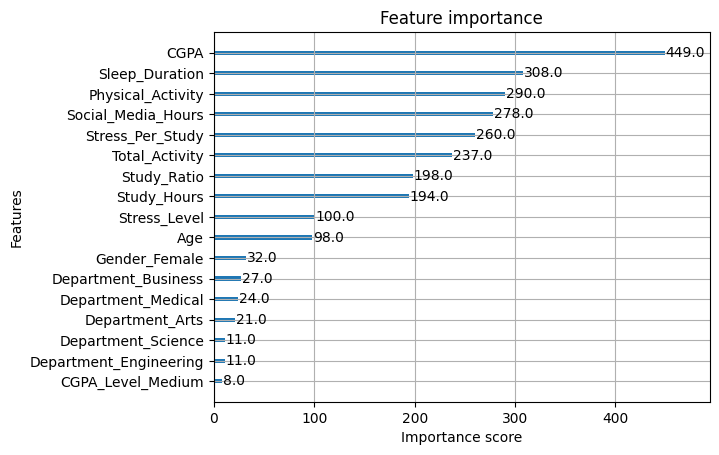

In [17]:
#============Xây dựng mô hình dự đoán mức độ trầm cảm sinh viên========================
#Tách dữ liệu
X = df.drop("Depression", axis=1)
y = df["Depression"]

#Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

#Xây dựng mô hình XGBoost
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42
)
#Train model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plot_importance(model)
plt.show()